# 🛒 E-Commerce Sales Analytics

## Milestone 2: Advanced Python Wrangling & Exploratory Data Analysis (EDA)

### Objective
This notebook focuses on cleaning, transforming, analyzing, and visualizing the E-Commerce Sales dataset using Python. The goal is to prepare the data for meaningful business insights and decision-making.

---

## Workflow

### 1. Import Required Libraries
- Import Python libraries required for data analysis and visualization.

### 2. Load the Dataset
- Read the raw E-Commerce Sales dataset into a Pandas DataFrame.

### 3. Dataset Overview
- Display the first few records
- Check dataset shape
- View column names
- Examine data types
- Generate statistical summary

### 4. Data Cleaning
- Inspect duplicate records
- Identify missing values
- Detect invalid records
- Verify data quality

### 5. Handle Missing & Invalid Data
- Treat missing values without deleting important transactional records.
- Handle invalid values using appropriate techniques.

### 6. Outlier Detection
- Detect statistical outliers using the IQR (Interquartile Range) method.
- Visualize outliers using box plots.

### 7. Feature Engineering
- Create a new **Order Value Category** column.
- Categorize orders into **Low**, **Medium**, and **High** value orders.

### 8. Exploratory Data Analysis (EDA)
- Analyze Revenue by Product Category
- Analyze Revenue by Region
- Analyze Regional Profit Distribution
- Analyze Order Value Categories
- Create visualizations to identify business trends

### 9. Key Insights
- Summarize important findings from the analysis.

### 10. Conclusion
- Present the overall conclusion of the E-Commerce Sales analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/E-Commerce Sales Analytics Dataset.csv")

In [ ]:
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,02-08-2025,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,17-08-2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,21-02-2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,18-07-2023,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,17-05-2023,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [ ]:
df.tail()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
5045,13907,29-07-2025,1181,Beauty,East,1,85.60,0.02,Card,8,4.3,83.89
5046,13774,16-09-2023,1158,Home,South,6,434.76,0.33,COD,10,2.6,1747.74
5047,14636,07-11-2024,1194,Beauty,East,3,245.15,0.26,COD,7,2.0,544.23
5048,13162,25-02-2025,1547,Home,East,4,470.40,0.02,COD,7,2.3,1843.97
5049,12660,28-02-2023,1736,Electronics,North,7,286.05,0.27,Card,4,3.1,1461.72


In [ ]:
df.shape

(5050, 12)

In [ ]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5050 non-null   int64  
 1   order_date        5050 non-null   object 
 2   customer_id       5050 non-null   int64  
 3   product_category  5010 non-null   object 
 4   region            5010 non-null   object 
 5   quantity          5050 non-null   int64  
 6   unit_price        5050 non-null   float64
 7   discount          5050 non-null   float64
 8   payment_method    5020 non-null   object 
 9   delivery_days     5050 non-null   int64  
 10  customer_rating   5050 non-null   float64
 11  revenue           5029 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 473.6+ KB


In [ ]:
df.describe()

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5029.000000
mean,12498.039208,1505.832079,4.049307,308.462762,0.179865,6.128713,2.974257,1076.168558
std,1444.697897,290.759852,2.019058,169.217691,0.101395,3.154512,1.157311,1658.498683
min,10001.000000,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,-3341.370000
25%,11244.250000,1253.000000,2.000000,161.937500,0.090000,3.000000,2.000000,356.120000
50%,12497.500000,1510.000000,4.000000,310.510000,0.180000,6.000000,3.000000,800.320000
75%,13748.750000,1760.750000,6.000000,455.377500,0.270000,9.000000,4.000000,1522.380000
max,15000.000000,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,62158.200000


In [ ]:
df.isnull().sum()

,0
order_id,0
order_date,0
customer_id,0
product_category,40
region,40
quantity,0
unit_price,0
discount,0
payment_method,30
delivery_days,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Handle Missing & Invalid Records

In [ ]:
df.isnull().sum()

for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_17198/2730000370.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_17198/2730000370.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [ ]:
df.isnull().sum()

,0
order_id,0
order_date,0
customer_id,0
product_category,0
region,0
quantity,0
unit_price,0
discount,0
payment_method,0
delivery_days,0


In [ ]:
df["region"] = df["region"].str.title()

In [ ]:
df["region"] = df["region"].str.strip()

In [ ]:
df["region"] = df["region"].str.strip().str.title()

In [ ]:
df["region"].unique()

array(['South', 'East', 'West', 'North'], dtype=object)

In [ ]:
df["product_category"] = df["product_category"].str.strip()

In [ ]:
df["product_category"] = df["product_category"].str.strip().str.title()

In [ ]:
df["product_category"].unique()

array(['Beauty', 'Clothing', 'Electronics', 'Home'], dtype=object)

# Handle Invalid Records

In [ ]:
for col in df.select_dtypes(include=[np.number]).columns:
    df = df[df[col] >= 0]

df.describe()

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,4947.000000,4947.000000,4947.000000,4947.000000,4947.000000,4947.000000,4947.000000,4947.000000
mean,12500.187588,1505.463513,3.998585,303.971421,0.181761,6.116636,2.974166,980.466408
std,1444.540803,291.308229,2.002071,167.370806,0.101080,3.154330,1.157093,763.955805
min,10001.000000,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11242.500000,1253.000000,2.000000,158.630000,0.100000,3.000000,2.000000,352.810000
50%,12501.000000,1510.000000,4.000000,304.850000,0.190000,6.000000,3.000000,788.370000
75%,13753.500000,1760.500000,6.000000,447.495000,0.270000,9.000000,4.000000,1462.820000
max,15000.000000,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,3162.360000


In [ ]:
df.to_csv("E-Commerce cleaned_data.csv", index=False)

In [ ]:
from google.colab import files
files.download("E-Commerce cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Outlier Detection (IQR Method)

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

df.shape

(4936, 13)

# Feature Engineering

In [ ]:
def categorize(value):
    if value < 1000:
        return "Low"
    elif value < 5000:
        return "Medium"
    else:
        return "High"

df["Order_Value_Category"] = df["revenue"].apply(categorize)

df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,Order_Value_Category
0,10001,02-08-2025,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,Medium
1,10002,17-08-2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,Low
2,10003,21-02-2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,Low
3,10004,18-07-2023,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,Medium
4,10005,17-05-2023,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,Low


# Revenue by Product Category

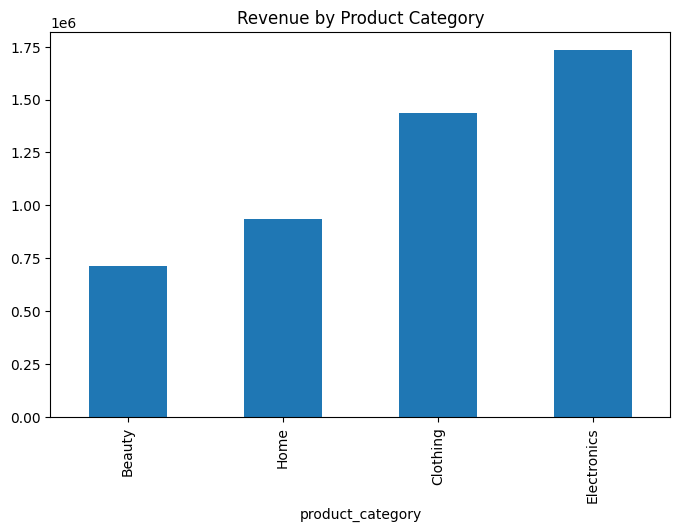

In [ ]:
category_revenue = df.groupby("product_category")["revenue"].sum().sort_values()

category_revenue.plot(kind="bar", figsize=(8,5))
plt.title("Revenue by Product Category")
plt.show()

# Revenue by Region

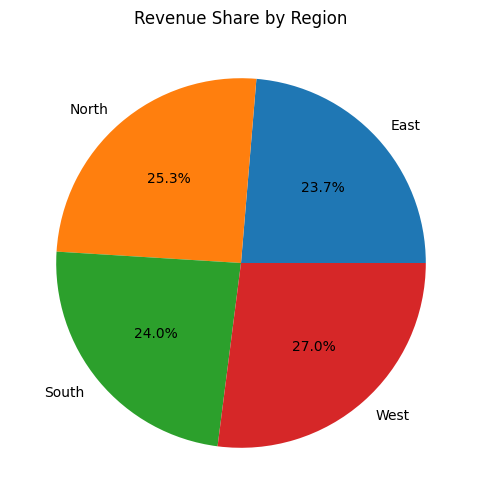

In [ ]:
region_revenue = df.groupby("region")["revenue"].sum()

region_revenue.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Revenue Share by Region")
plt.ylabel("")
plt.show()

# Monthly Trend

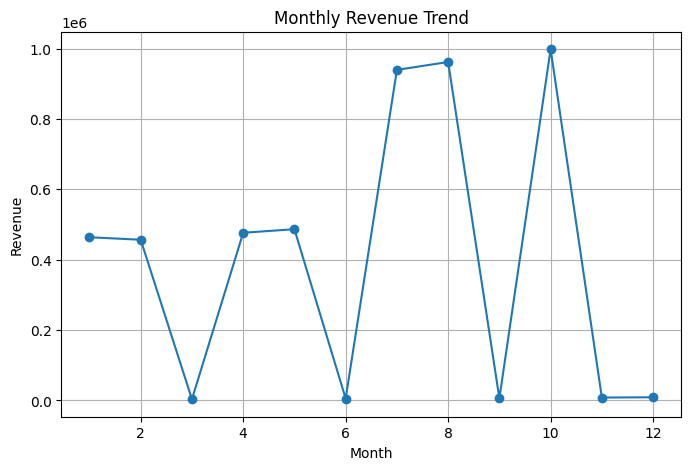

In [ ]:
df["order_date"] = pd.to_datetime(df["order_date"], format='%d-%m-%Y')

monthly_revenue = df.groupby(df["order_date"].dt.month)["revenue"].sum()

monthly_revenue.plot(kind="line", marker="o", figsize=(8,5))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

# Top Product Categories

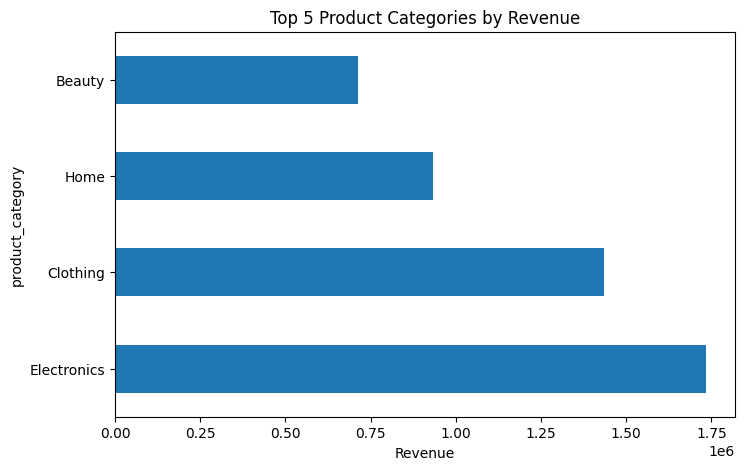

In [ ]:
top5 = df.groupby("product_category")["revenue"].sum().sort_values(ascending=False).head(5)

top5.plot(kind="barh", figsize=(8,5))
plt.title("Top 5 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.show()

# Order Value Category Analysis

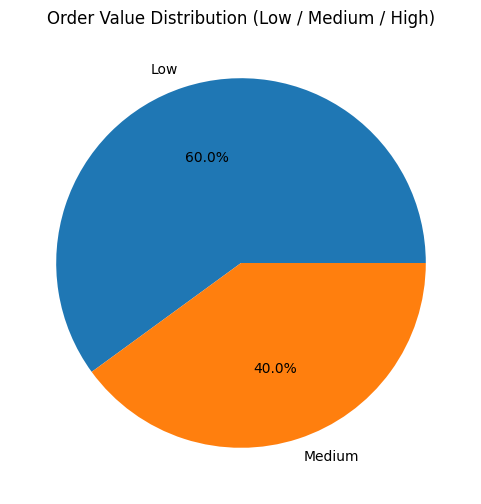

In [ ]:
order_value_dist = df["Order_Value_Category"].value_counts()

order_value_dist.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Order Value Distribution (Low / Medium / High)")
plt.ylabel("")
plt.show()

# Correlation Heatmap

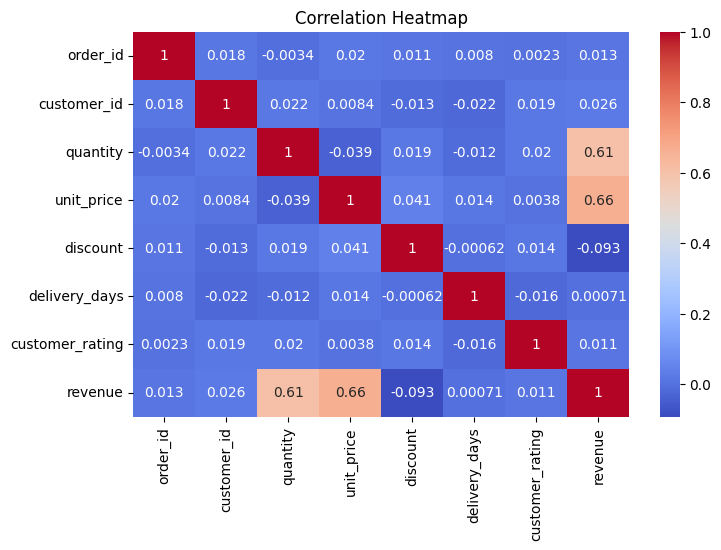

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

# Key Insights

In [ ]:
print("""
FINAL INSIGHTS:

1. Product categories show different revenue contributions.
2. Regional analysis highlights top-performing regions.
3. Majority orders fall into Low/Medium value segment.
4. Data cleaning improved accuracy of analysis.
5. Trends help understand customer purchasing behavior.
""")


FINAL INSIGHTS:

1. Product categories show different revenue contributions.
2. Regional analysis highlights top-performing regions.
3. Majority orders fall into Low/Medium value segment.
4. Data cleaning improved accuracy of analysis.
5. Trends help understand customer purchasing behavior.



## Conclusion

This project successfully performed data cleaning, transformation, and exploratory data analysis on the E-Commerce dataset.

Key insights were derived from:
- Product category performance
- Regional revenue distribution
- Order value segmentation
- Trend analysis

The analysis helps in understanding customer behavior and supports data-driven business decisions.